## SHAP-Werte berechnen mittels CV und globaler Plot 

In [15]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Maestroni_ML.xlsx",
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")




SHAP-Wertprüfung:
→ Min: -5110.149076740888 Max: 4.7204627826226355 Mean: -1.4610448618903709
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
INV_CMJ_uni_Propulsive Duration-Mittelwert [s]                    -39.379576       39.443405
INV_CMJ_uni_Av. propulsive force                                   -0.004830        0.849665
UNINV_CMJ_uni_Peak braking force                                   +0.020781        0.820244
INV_CMJ_uni_Relative Peak Landing Force-Mittelwert [BW]            -0.007553        0.776924
CMJ_Braking duration                                               +0.006558        0.563208
UNINV_CMJ_uni_Peak Propulsive Force-Mittelwert [N]                 +0.006612        0.531613
LSI_ISO_Extension                                                  -0.001327        0.531485


## SHAP Kontrolle

In [16]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end   = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap   = []
p_from_model  = []

for i in idx_local:
    logit_i = exp_val + shap_stack[i].sum()        # log-odds rekonstruiert
    p_from_shap.append(expit(logit_i))             # -> Wahrscheinlichkeit
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap  = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model
print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")




=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 5.551e-17
Mittlere Abweichung : 1.943e-17
Median Abweichung   : 0.000e+00

P_SHAP=0.479586 | P_Modell=0.479586 | Δ=+0.00e+00
P_SHAP=0.978539 | P_Modell=0.978539 | Δ=+0.00e+00
P_SHAP=0.271158 | P_Modell=0.271158 | Δ=+5.55e-17
P_SHAP=0.980407 | P_Modell=0.980407 | Δ=+0.00e+00
P_SHAP=0.083549 | P_Modell=0.083549 | Δ=+4.16e-17


## Globaler SHAP Plot

→ Globaler Diverging Bar-Plot: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\global_diverging_bar.png


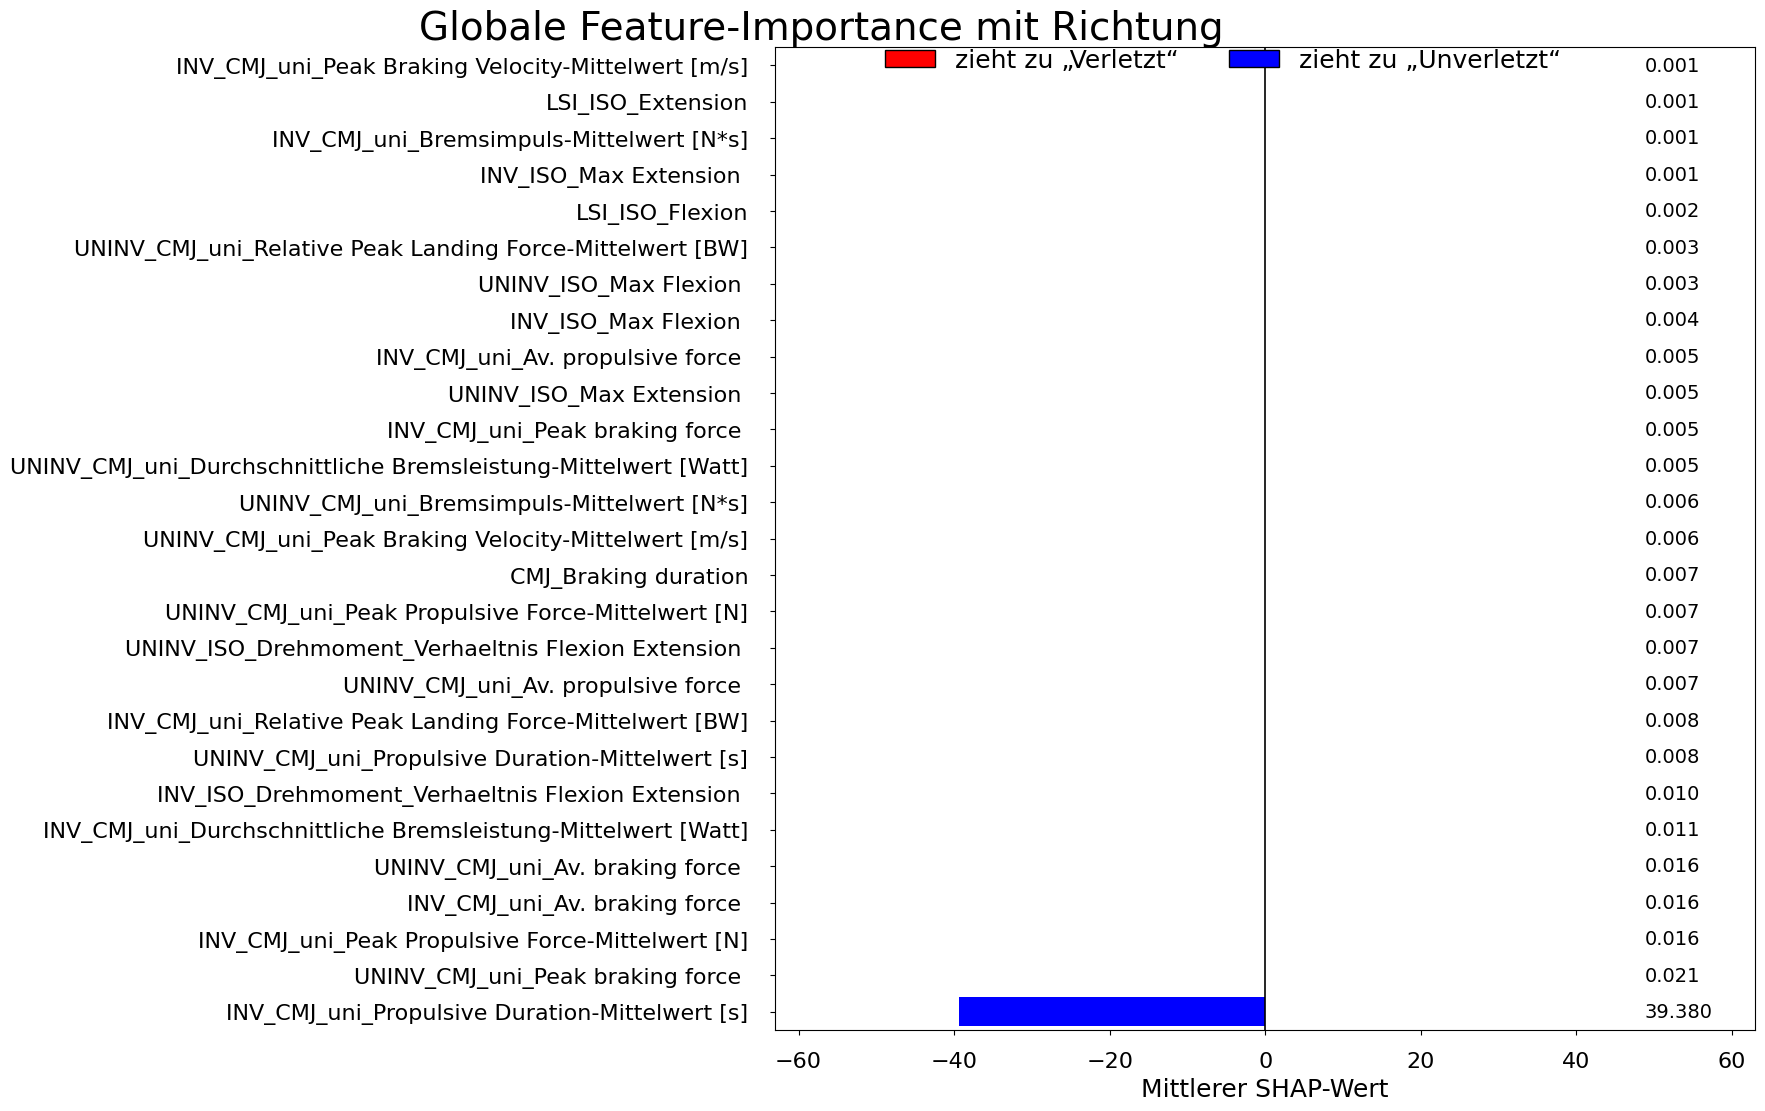

In [17]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

shap_output_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"

def plot_global_diverging_bar(
    features, 
    shap_stack, 
    output_dir, 
    title="Globale Feature-Importance mit Richtung",
    dpi=200
):
    """
    Zeichnet einen Diverging Bar-Plot:
      - rote Balken → höhere P(Verletzt),
      - blaue Balken → höhere P(Unverletzt).
    Ganz rechts außerhalb der Balken werden die absoluten mittleren SHAP-Werte
    angezeigt. Überschrift und Legende im Kopfbereich, Plot unten bündig.
    """
    # 1) Mittelwerte berechnen und sortieren
    mean_shap = np.mean(shap_stack, axis=0)
    idx_sort  = np.argsort(np.abs(mean_shap))[::-1]
    feat_sorted      = [features[i] for i in idx_sort]
    mean_shap_sorted = mean_shap[idx_sort]
    abs_sorted       = np.abs(mean_shap_sorted)
    colors           = ['red' if v>=0 else 'blue' for v in mean_shap_sorted]

    # 2) Puffer & Limits
    max_abs = abs_sorted.max()
    margin  = max_abs * 0.6

    # 3) Figur bauen
    fig_h = max(10, len(feat_sorted) * 0.4)
    fig_w = 14
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    # Überschrift im Kopfbereich, zentriert und größer
    fig.suptitle(title, fontsize=28, y=0.965, ha='right')

    # 4) Legende ebenfalls im Kopfbereich, zentriert unter dem Titel
    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    fig.legend(
        handles=legend_elements,
        fontsize=18,
        loc='upper center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.95),
        frameon=False
    )

    # 5) Balken zeichnen
    ax.barh(feat_sorted, mean_shap_sorted, color=colors, height=0.8)
    ax.axvline(0, color='black', linewidth=1.2)

    # 6) Achsen & Limits
    ax.set_xlabel("Mittlerer SHAP-Wert", fontsize=18)
    ax.tick_params(axis='y', labelsize=16, pad=16)
    ax.tick_params(axis='x', labelsize=16, pad=12)
    ax.set_xlim(-max_abs - margin, max_abs + margin)

    # 7) Zahlen ganz rechts
    x_text = max_abs + margin * 0.4
    for i, val in enumerate(abs_sorted):
        ax.text(
            x_text,
            i,
            f"{val:.3f}",
            va='center',
            ha='left',
            fontsize=14
        )

    # 8) Plot unten bündig anschließen
    ax.set_ylim(-0.5, len(feat_sorted)-0.5)
    ax.margins(y=0)

    # 9) Layout: Platz oben für Suptitle + Legend, bündig unten
    plt.subplots_adjust(top=0.93, bottom=0.02, left=0.18, right=0.88)

    # 10) Speichern & Anzeigen
    out = os.path.join(output_dir, "global_diverging_bar.png")
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f"→ Globaler Diverging Bar-Plot: {out}")
    plt.show()

# Aufruf
plot_global_diverging_bar(
    features=features, 
    shap_stack=shap_stack, 
    output_dir=shap_output_dir
)

### Top-N Globaler Plot

→ Top-10-Plot gespeichert unter: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\global_diverging_bar_top10_rest.png


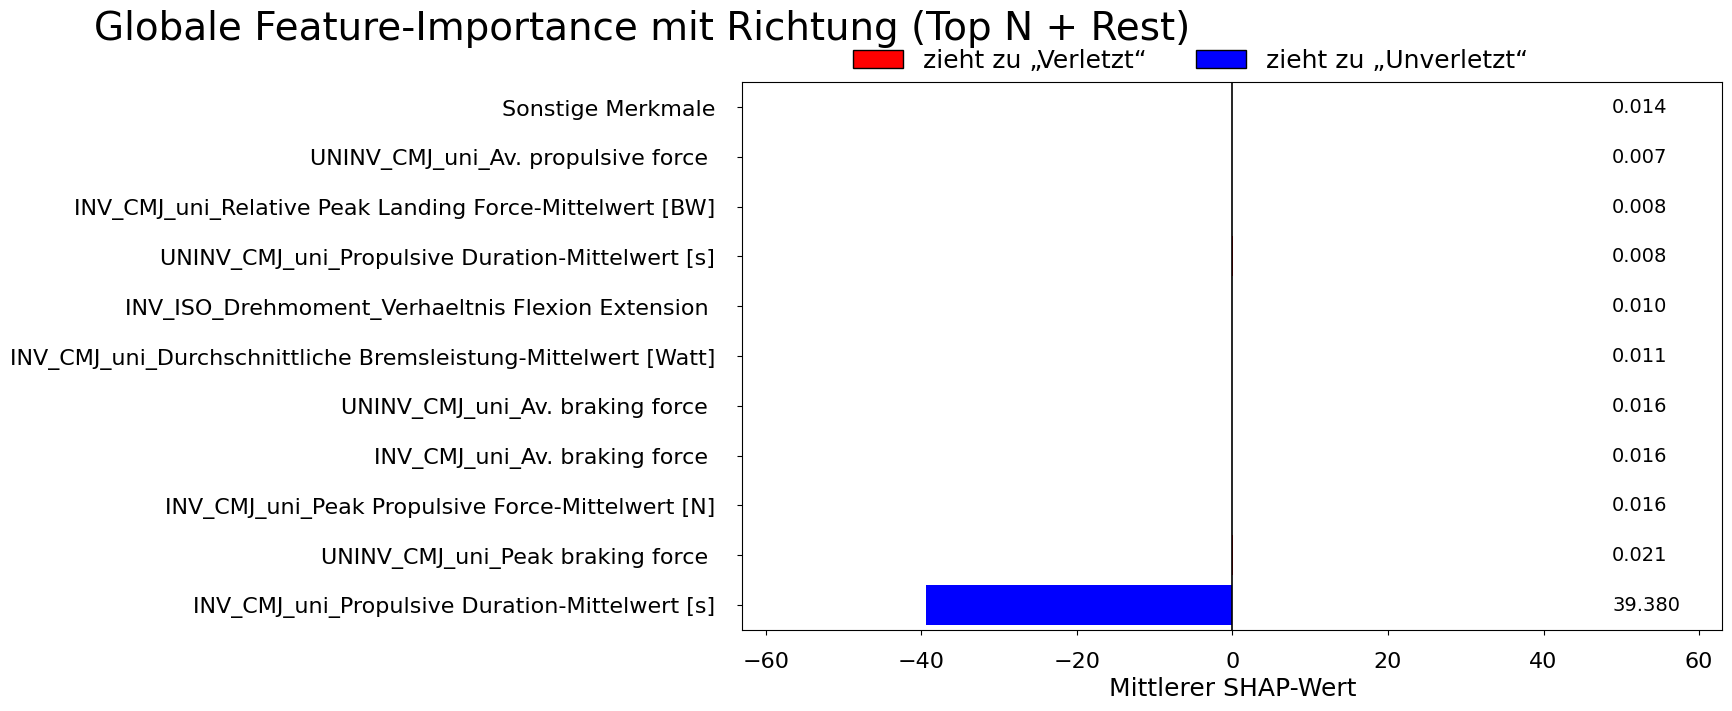

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_global_diverging_bar_topN_with_rest(
    features,
    shap_stack,
    output_dir,
    title="Globale Feature-Importance mit Richtung (Top N + Rest)",
    dpi=200,
    top_n=10  # NEU: Variable Anzahl an Top-Features
):
    mean_shap = np.mean(shap_stack, axis=0)
    abs_mean_shap = np.abs(mean_shap)
    idx_sort = np.argsort(abs_mean_shap)[::-1]

    # Top-N Features und Rest
    top_idxs = idx_sort[:top_n]
    rest_idxs = idx_sort[top_n:]

    top_features = [features[i] for i in top_idxs]
    top_values = mean_shap[top_idxs]
    top_colors = ['red' if val >= 0 else 'blue' for val in top_values]

    # "Rest" berechnen
    rest_value = np.sum(mean_shap[rest_idxs])
    rest_color = 'red' if rest_value >= 0 else 'blue'

    # Plot-Daten zusammenbauen
    bar_labels = top_features + ['Sonstige Merkmale']
    bar_values = np.append(top_values, rest_value)
    bar_colors = top_colors + [rest_color]
    abs_bar_values = np.abs(bar_values)

    # Plotgröße
    fig_h = max(6, len(bar_labels) * 0.6)
    fig_w = 14
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    
    # Legende im Kopfbereich
    legend_elements = [
        Patch(facecolor='red', edgecolor='k', label='zieht zu „Verletzt“'),
        Patch(facecolor='blue', edgecolor='k', label='zieht zu „Unverletzt“')
    ]
    # Titel und Legende im Kopfbereich kompakt zusammen
    fig.suptitle(title, fontsize=28, y=0.96, ha='right')

    fig.legend(
        handles=legend_elements,
        fontsize=18,
        loc='upper center',
        ncol=2,
        bbox_to_anchor=(0.5, 0.935),  # direkt unter dem Titel
        frameon=False
    )


    # Balken zeichnen
    ax.barh(bar_labels, bar_values, color=bar_colors, height=0.8)
    ax.axvline(0, color='black', linewidth=1.2)

    # Achsen & Beschriftung
    max_abs = abs_bar_values.max()
    margin = max_abs * 0.6
    ax.set_xlim(-max_abs - margin, max_abs + margin)
    ax.set_xlabel("Mittlerer SHAP-Wert", fontsize=18)
    ax.tick_params(axis='y', labelsize=16, pad=16)
    ax.tick_params(axis='x', labelsize=16, pad=12)

    # SHAP-Werte als Text rechts
    x_text = max_abs + margin * 0.4
    for i, val in enumerate(abs_bar_values):
        ax.text(
            x_text,
            i,
            f"{val:.3f}",
            va='center',
            ha='left',
            fontsize=14
        )

    # Layout optimieren
    ax.set_ylim(-0.5, len(bar_labels)-0.5)
    ax.margins(y=0)
    plt.subplots_adjust(top=0.85, bottom=0.02, left=0.18, right=0.88)

    # Speichern & Anzeigen
    out_path = os.path.join(output_dir, f"global_diverging_bar_top{top_n}_rest.png")
    fig.savefig(out_path, dpi=dpi, bbox_inches='tight')
    print(f"→ Top-{top_n}-Plot gespeichert unter: {out_path}")
    plt.show()

plot_global_diverging_bar_topN_with_rest(
    features=features,
    shap_stack=shap_stack,
    output_dir=shap_output_dir,
    top_n=10
)


### Lokaler Plot

C:\Users\boehmer\AppData\Local\Temp\ipykernel_1188\3010490875.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(pad=2)                                  # 2pt Abstand zu Figure-Rand


→ Lokaler Waterfall-Plot mit Kopfzeile: K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP\local_waterfall_4.png


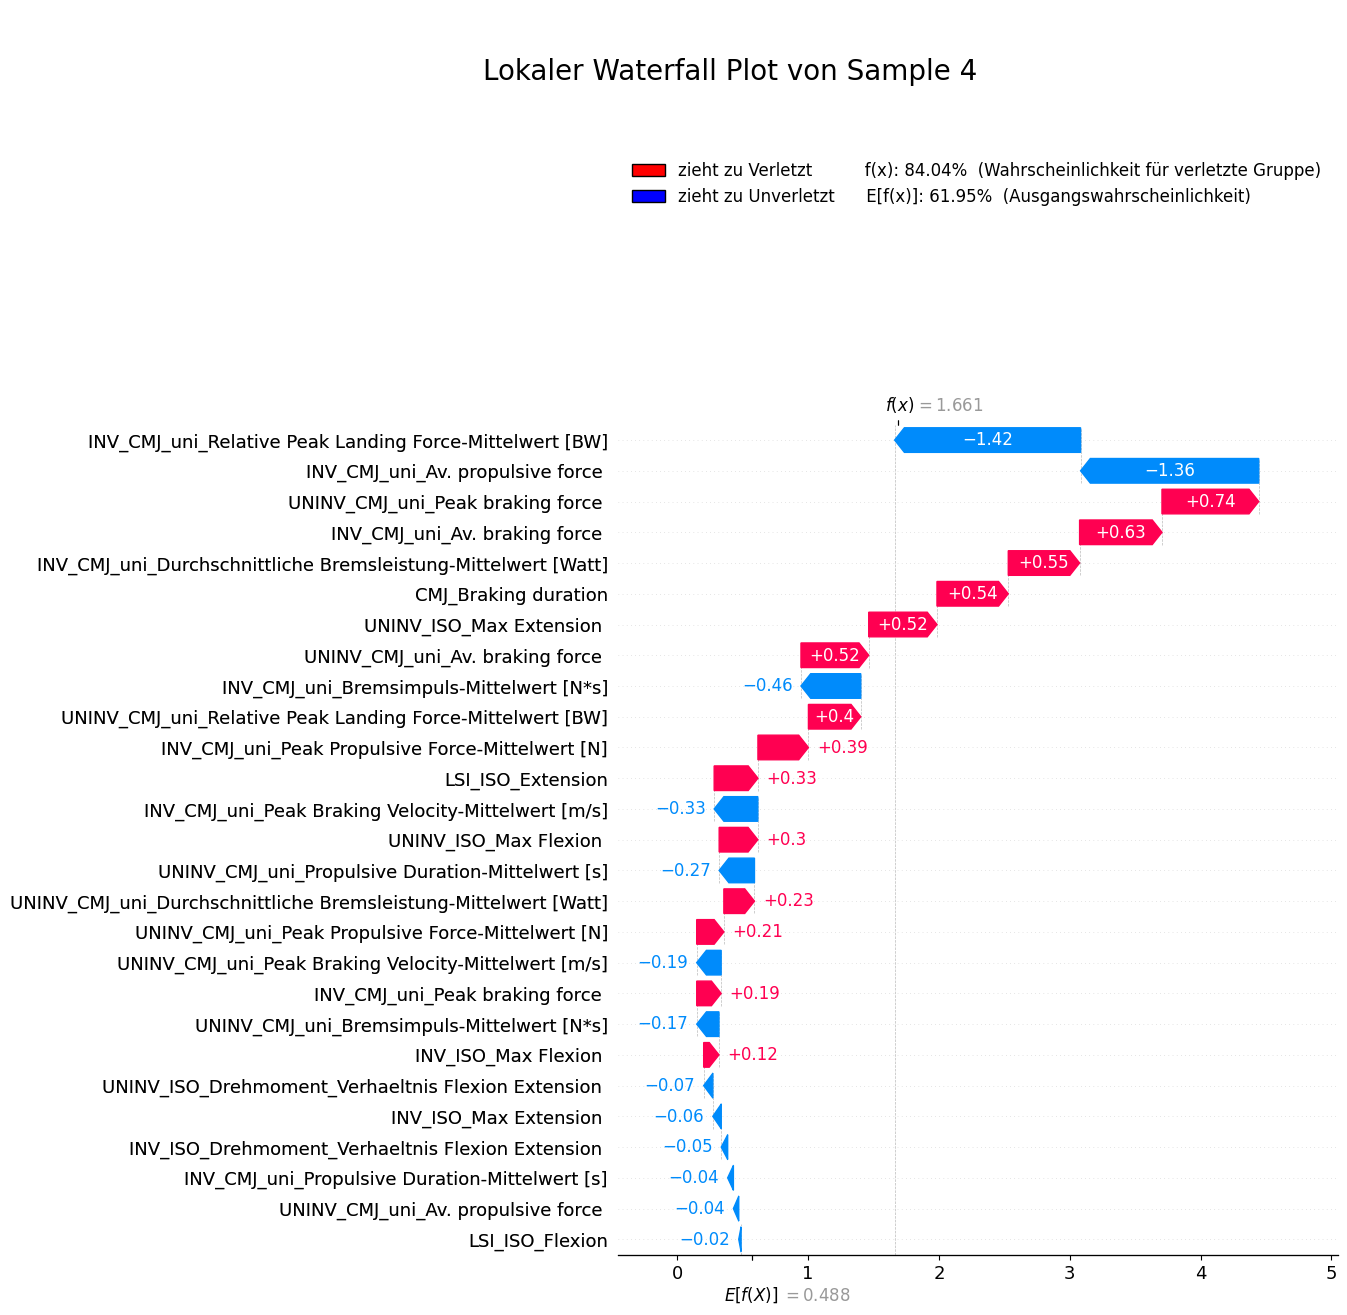

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import shap
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from scipy.special import expit 

shap_output_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"

def plot_local_waterfall(
    features,
    shap_stack,
    X_stack,
    exp_val,
    output_dir,
    sample_idx=None,
    dpi=200
):
    """
    Zeichnet einen lokalen SHAP-Waterfall-Plot mit:
      - Kopfzeile (Title + Legende) im oberen Bereich
      - Direkt darunter den Waterfall, tight am Rand
      - Zusammenfassung aller SHAP=0 Features
    """
    # 1) Sample wählen
    if sample_idx is None:
        np.random.seed(42)
        sample_idx = np.random.choice(shap_stack.shape[0], 1)[0]

    # 2) SHAP-Werte & -Namen
    orig_vals = shap_stack[sample_idx, :]
    orig_names = list(features)

    # 3) Null-Werte zusammenfassen
    zero_mask = orig_vals == 0
    vals_nz   = orig_vals[~zero_mask].tolist()
    names_nz  = [orig_names[i] for i in range(len(orig_names)) if not zero_mask[i]]
    if zero_mask.sum() > 0:
        names_nz.append("Restliche Null-Features")
        vals_nz.append(0.0)

    # 4) Explanation aufbauen
    exp = shap.Explanation(
        values        = np.array(vals_nz),
        base_values   = exp_val,
        feature_names = names_nz,
    )


    fx_logit = exp_val + sum(vals_nz)      # f(x) im Logit
    p_fx     = expit(fx_logit)             # Wahrscheinlichkeit
    p_base   = expit(exp_val)              # Baseline-Wahrscheinlichkeit


    # 5) Figure + GridSpec: 20% Kopf, 80% Plot
    fig = plt.figure(figsize=(10, max(8, len(names_nz)*0.15) + 2))
    gs  = gridspec.GridSpec(
        nrows=2, ncols=1,
        height_ratios=[0.2, 0.8],
        hspace=0.4
    )

    # 6) Kopf-Bereich (unsichtbare Achse)
    ax_header = fig.add_subplot(gs[0])
    ax_header.axis("off")
    ax_header.text(
        0.5, 0.7,
        f"Lokaler Waterfall Plot von Sample {sample_idx}",
        ha="right", va="center",
        fontsize=20
    )

    # Patch-Legende in den Kopfbereich
    legend_elements = [
        Patch(facecolor='red',  edgecolor='k', label=f'zieht zu Verletzt          f(x): {p_fx:.2%}  (Wahrscheinlichkeit für verletzte Gruppe)'),
        Patch(facecolor='blue', edgecolor='k', label=f'zieht zu Unverletzt      E[f(x)]: {p_base:.2%}  (Ausgangswahrscheinlichkeit)')
    ]
    ax_header.legend(
        handles=legend_elements,
        fontsize=12,
        loc='upper left',
        bbox_to_anchor=(0.01, 0.3),
        borderaxespad=0.,
        frameon=False
    )



    # 7) Plot-Bereich
    ax_plot = fig.add_subplot(gs[1])
    plt.sca(ax_plot)
    shap.plots.waterfall(
        exp,
        show=False,
        max_display=len(names_nz)
    )


    # 9) Tight am unteren Rand, Sortierung beibehalten
    # ax_plot.set_ylim(-0.5, len(names_nz)-0.5)
    # ax_plot.margins(y=0)
    # plt.tight_layout(pad=0)
    ax_plot.set_ylim(-0.5, len(names_nz)-0.5)
    ax_plot.margins(x=0.025, y=0.22)                          # 5% links/rechts, 2% oben/unten
    plt.tight_layout(pad=2)                                  # 2pt Abstand zu Figure-Rand
    fig.subplots_adjust(left=0.05, right=0.95, bottom=0.05)  # 5% Abstand links/rechts/unten

    # 9) Speichern und ausgeben
    out = os.path.join(output_dir, f"local_waterfall_{sample_idx}.png")
    fig.savefig(out, dpi=dpi, bbox_inches='tight')
    print(f"→ Lokaler Waterfall-Plot mit Kopfzeile: {out}")
    plt.show()


# Aufruf
plot_local_waterfall(
    features=features,
    shap_stack=shap_stack,
    X_stack=X_stack,
    exp_val=exp_val,
    output_dir=shap_output_dir,
    sample_idx=4   # None = zufälliges Sample
)

## Beeswarm und Dependence Plots (Versuch)

In [18]:
# === SHAP: Beeswarm & Dependence nur für Features mit hohem |signed_mean_shap| ===
import os
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
warnings.filterwarnings("ignore")

out_dir = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\SHAP"
os.makedirs(out_dir, exist_ok=True)

# 1) Auswahl/Sortierung nach |signed_mean_shap|
order = np.argsort(np.abs(signed_mean_shaps))[::-1]
top_k = 5  # nach Bedarf anpassen
sel_idx = order[:top_k]
sel_features = [features[i] for i in sel_idx]
print("Top-Features (|signed_mean_shap|):", sel_features)

# 2) Beeswarm NUR mit den ausgewählten Features
X_sel    = X_stack[:, sel_idx]
shap_sel = shap_stack[:, sel_idx]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_sel, X_sel, feature_names=sel_features, show=False)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "beeswarm_top_by_signed_mean.png"),
            dpi=300, bbox_inches="tight")
plt.close()

# 3) Dependence-Plots für die ausgewählten Features
for i, feat_idx in enumerate(sel_idx):
    fname = features[feat_idx]
    plt.figure(figsize=(7.5, 6))
    # Achtung: dependence_plot erwartet globales Array + Index
    shap.dependence_plot(feat_idx, shap_stack, X_stack, feature_names=features, show=False)
    plt.title(f"SHAP Dependence – {fname}")
    plt.tight_layout()
    safe_name = fname.replace('/', '_').replace(':','-')
    plt.savefig(os.path.join(out_dir, f"dep_signedmean_{i:02d}_{safe_name}.png"),
                dpi=300, bbox_inches="tight")
    plt.close()


Top-Features (|signed_mean_shap|): ['INV_CMJ_uni_Propulsive Duration-Mittelwert [s]', 'UNINV_CMJ_uni_Peak braking force ', 'INV_CMJ_uni_Peak Propulsive Force-Mittelwert [N]', 'INV_CMJ_uni_Av. braking force ', 'UNINV_CMJ_uni_Av. braking force ']
